# Homework 2: Probability Models

BEE 4850/5850

**Name**: Madeline Allen

**ID**: mca76

> **Due Date**
>
> Friday, 2/21/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice developing and
working with probability models for data.

-   Problem 1 asks you to fit a sea-level rise model using normal
    residuals and to assess the validity of that assumption.
-   Problem 2 asks you to model the time series of hourly
    weather-related variability at a tide gauge using an autoregressive
    model.
-   Problem 3 asks you to use Poisson regression to predict salamander
    counts based on environmental data.
-   Problem 4 (only required for students in BEE 5850) asks you to look
    at the impact of the gender of hurricane names on deaths[1].

[1] Yes, seriously. Ish. Trust me, I know.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [ ]:
# Not using Juila; commented out this code
# import Pkg
# Pkg.activate(@__DIR__)
# Pkg.instantiate()

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [ ]:
# using Random # random number generation and seed-setting
# using DataFrames # tabular data structure
# using CSV # reads/writes .csv files
# using Distributions # interface to work with probability distributions
# using Plots # plotting library
# using StatsBase # statistical quantities like mean, median, etc
# using StatsPlots # some additional statistical plotting tools
# using Optim # optimization tools

I asked Chatgpt (OpenAI, 2024) "what are python equivalent packages to these julia packages" with the code block above pasted below it. The only two it recommended that I didn't use last time were scipy.optimize and random.

In [15]:
# Import packages:
import pandas as pd
import numpy as np 
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns 
import random  
import scipy.optimize as optimize

## Problems

### Scoring

-   Problem 1 is worth 7 points.
-   Problem 2 is worth 6 points.
-   Problem 3 is worth 7 points.
-   Problem 4 is worth 5 points.

### Problem 1

Consider the following sea-level rise model from [Grinsted et al
(2010)](https://doi.org/10.1007/s00382-008-0507-2), which models
sea-level rise based on a linear relationship between global mean
temperature and an “equilibrium” sea level:

$$\begin{align*}
\frac{dS}{dt} &= \frac{S_\text{eq} - S}{\tau} \\
S_\text{eq} &= aT + b,
\end{align*}
$$

where

-   $S(t)$ is the global mean sea level (in mm) at time $t$;
-   $\tau$ is the response time of sea level (in yrs);
-   $S_\text{eq}$ is the equilibrium sea-level (in mm) at temperature
    $T$ (in $^\circ$ C);
-   $a$ is the sensitivity of $S_\text{eq}$ to $T$ (in mm/$^\circ$ C);
-   $b$ is the intercept of $S_\text{eq}$, or the $S_\text{eq}$ when
    $T=0^\circ$ C (in mm).

**In this problem**:

-   Load the data from the `data/` folder and, following Grinsted et al
    (2010), normalize both datasets to the 1980-1999 mean (subtract that
    mean from the data).
    -   Global mean temperature data from the HadCRUT 5.0.2.0 dataset
        (<https://hadobs.metoffice.gov.uk/hadcrut5/data/HadCRUT.5.0.2.0/download.html>)
        can be found in
        `data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv`.
        This data is averaged over the Northern and Southern Hemispheres
        and over the whole year.
    -   Global mean sea level anomalies (relative to the 1990 mean
        global sea level) are in `data/CSIRO_Recons_gmsl_yr_2015.csv`,
        courtesy of CSIRO
        (<https://www.cmar.csiro.au/sealevel/sl_data_cmar.html>). The
        standard deviation of the estimate is also added for each year.
-   Write a function to simulate global mean sea levels under a set of
    model parameters after discretizing the equations above with a
    timestep of $\delta t = 1$ yr. You will need to subset the
    temperature data to the years where you also have sea-level data.
-   Fit the model under the assumption of Gaussian i.i.d. residuals
    (include both an uncertain model error term and the standard
    deviation of the observations in the probability model
    specification) by maximizing the likelihood. Report the parameter
    estimates. Note that you will need another parameter $S_0$ for the
    initial sea level. What can you conclude about the relationship
    between global mean temperature increases and global mean sea level
    rise rates?
-   How appropriate was the Gaussian i.i.d. probability model for the
    residuals? Use any needed quantitative or qualitative assessments of
    goodness of fit to justify your answer. If this was not an
    appropriate probability model, what would you change?

In [36]:
#  Load data
temp = pd.read_csv("data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv") 
sea = pd.read_csv("data/CSIRO_Recons_gmsl_yr_2015.csv") 
# Round down the time on sea_lev_anom for simplicity, since 1880.5 is the mean sea level in 1880, as noted in ed discussion post
sea['Time'] = sea['Time'].astype(int)
# print(temp.head(10))
# print(sea.head(10))

# normalize both datasets to the 1980-1999 mean
temp_mean = temp[(temp['Time']>=1980) & (temp['Time']<=1999)]['Anomaly (deg C)'].mean()
print('Mean temp anomaly from 1980-1999:', temp_mean)
sea_mean = sea[(sea['Time']>=1980) & sea['Time']<=1999]['GMSL (mm)'].mean()
print('Mean sea level anomaly from 1980-1999:', sea_mean)

# subtract mean from data:
temp['temp_anom_normalized'] = temp['Anomaly (deg C)'] - temp_mean
sea['GMSL_anom_normalized'] = sea['GMSL (mm)'] - sea_mean
# print(temp.head(10))
# print(sea.head(10))


Mean temp anomaly from 1980-1999: 0.24016621270000002
Mean sea level anomaly from 1980-1999: -66.0813432835821


In [37]:
# Figure out what years both datasets contain:
temp['Time'].min()
sea['Time']

0      1880
1      1881
2      1882
3      1883
4      1884
       ... 
129    2009
130    2010
131    2011
132    2012
133    2013
Name: Time, Length: 134, dtype: int64

Write a function to simulate global mean sea levels under a set of
    model parameters after discretizing the equations above with a
    timestep of $\delta t = 1$ yr. You will need to subset the
    temperature data to the years where you also have sea-level data

In [ ]:
# Function: simualte global simulate global mean sea levels under a set of model parameters
# using discretized equations above w/ timestep of $\delta t = 1$ yr



### Problem 2

Tide gauge data is complicated to analyze because it is influenced by
different harmonic processes (such as the linear cycle). In this
problem, we will develop a model for this data using [NOAA data from the
Sewell’s Point tide
gauge](https://tidesandcurrents.noaa.gov/waterlevels.html?id=8638610)
outside of Norfolk, VA from `data/norfolk-hourly-surge-2015.csv`. This
is hourly data (in m) from 2015 and includes both the observed data
(`Verified (m)`) and the tide level predicted by NOAA’s sinusoidal model
for periodic variability, such as tides and other seasonal cycles
(`Predicted (m)`).

**In this problem**:

-   Load the data file. Take the difference between the observations and
    the sinusoidal predictions to obtain the tide level which could be
    attributed to weather-related variability (since for one year
    sea-level rise and other factors are unlikely to matter). Plot this
    data.
-   Develop an autoregressive (AR) model for the weather-related
    variability in the Norfolk tide gauge. Make sure to include your
    logic or exploratory analysis used in determining the model
    specification.
-   Use your model to simulate 1,000 realizations of hourly tide gauge
    observations by adding simulations from your AR model back to the
    predicted sinusoidal trend. What is the distribution of the maximum
    tide level? How does this compare to the observed value?

In [44]:
#  Load data - surge, hourly data (in m)
surge = pd.read_csv("data/norfolk-hourly-surge-2015.csv") 
# Combine date and time columns (I'm not positive if this is actually necessary, but I thought if
# I only plotted a variable against Date then datapoints would be stacked on top of each other)
surge['datetime'] = pd.to_datetime(surge['Date'] + ' ' + surge['Time (GMT)'])
print(surge.head(5))


         Date Time (GMT)  Predicted (m) Preliminary (m)  Verified (m)  \
0  2015/01/01      00:00          0.480               -         0.616   
1  2015/01/01      01:00          0.325               -         0.432   
2  2015/01/01      02:00          0.145               -         0.242   
3  2015/01/01      03:00         -0.009               -         0.084   
4  2015/01/01      04:00         -0.099               -        -0.006   

             datetime  
0 2015-01-01 00:00:00  
1 2015-01-01 01:00:00  
2 2015-01-01 02:00:00  
3 2015-01-01 03:00:00  
4 2015-01-01 04:00:00  


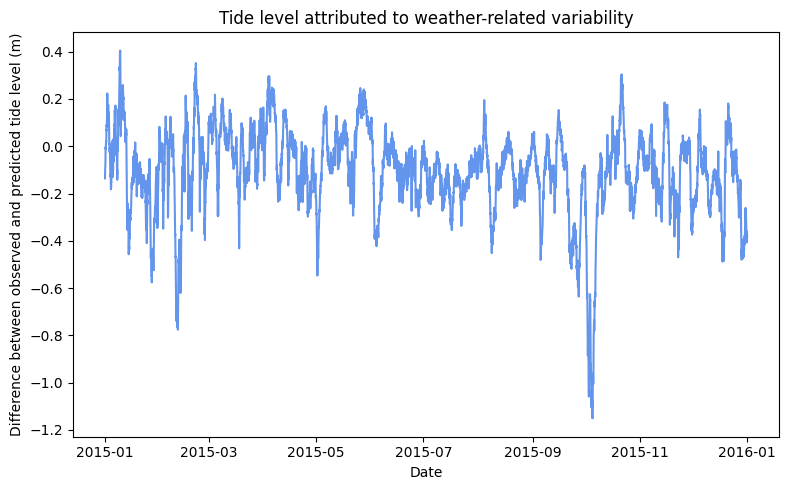

In [ ]:
# Take difference between the observations and predictions 
# to obtain the tide level which could be attributed to weather-related variability 
surge['weather_variability'] = surge['Predicted (m)'] - surge['Verified (m)']

# Plot:
plt.figure(figsize=(8,5)) 
plt.plot(surge['datetime'],surge['weather_variability'], color='cornflowerblue')#, label='No Cheat')#, alpha = 0.8)
# Add labels
plt.xlabel('Date')
plt.ylabel('Difference between observed and predicted tide level (m)')
plt.title('Tide level attributed to weather-related variability')
plt.tight_layout()
plt.show()

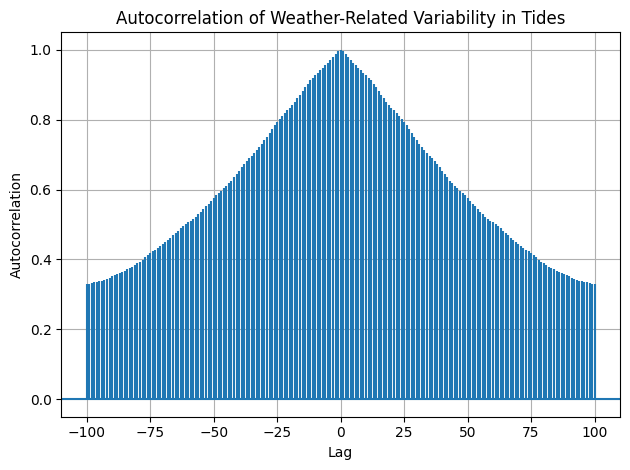

In [ ]:
# Develop an autoregressive (AR) model for the weather-related variability in the Norfolk tide gauge. 
# Include your logic/exploratory analysis used in determining the model

# Autocorrelation plot
plt.acorr(surge['weather_variability'], maxlags = 100) 
plt.grid(True)

# Add labels
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation of Weather-Related Variability in Tides')
plt.tight_layout()
plt.show()

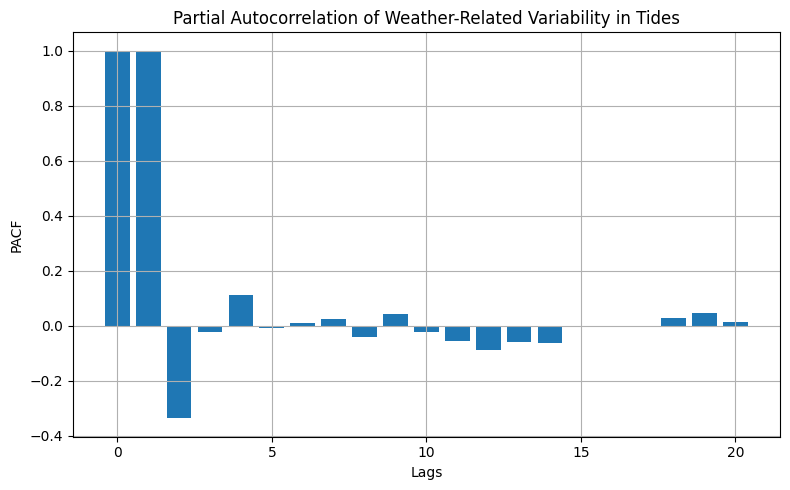

In [65]:
# Calculate PACF using statsmodels pacf function
# Note - I used chatgpt to figure out what the appropriate packages to use here; I asked 
# "how to compute and plot partial autocorrelation in python" and only used the lines of code that read in
# the packages correctly because I already had the plotting code from matplotlib documentation that used statsmodels functions.
# also note that by default this statsmodels package uses "ywadjusted” for the method - which is 
# "Yule-Walker with sample-size adjustment in denominator for acovf" 
# (statsmodels, 2024)
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_pacf
pacf_values = pacf(surge['weather_variability'], nlags=20, method='ywadjusted') # ols-adjusted #ywadjusted


# Plot PACF
plt.figure(figsize=(8, 5))
plt.bar(range(len(pacf_values)), pacf_values)
plt.title('Partial Autocorrelation of Weather-Related Variability in Tides')
plt.xlabel('Lags')
plt.ylabel('PACF')
plt.grid(True)
plt.tight_layout()
plt.show()

After plotting the initial autocorrelation plot, I realized that using autocorrelation instead of partial autocorrelation, I was seeing the effects that were noted in class lecture - i.e., that by only computing autocorrelation (using synthetically created data that only had a lag-1 dependence), we can still see evidence of autocorrelation between lag times beyond 1 lag. As done in lecture - in order to isolate zeta(i) independent of zeta(i-k), we can use partial autocorrelation, as done above. Note that the statsmodel package I uses a "Yule-Walker with sample-size adjustment in denominator for acovf" method to determine the partial autocorrelation (statsmodels, 2024); I used this method, and also tried the adjusted OLS method which did not result in any noticeable differences; for a more thorough analysis I would examine whether a different method of calculating the partial autocorrelation would be more appropriate for this use case (but here, just used the default method - adjusted Yule-Walker). The results of the partial autocorrelation shown in the figure above show that there is a very strong autocorrelation in the first two lag times (both ~1, which seems surprising); and essentially no autocorrelation after lag 2 (which was not surprising to me). As such, I chose to use an AR(2) model.

To code the AR model, I first copied and pasted the Julia code for the AR(1) model developed in the lecture slides into chatgpt (OpenAI, 2024) and asked it to convert it from Julia to Python; the resulting python code (not for this problem/context) is copied below and commented out.

In [92]:
# import numpy as np
# from scipy.stats import norm, multivariate_normal
# from scipy.optimize import minimize
# import matplotlib.pyplot as plt

# # Function to compute the log-likelihood using the whitened approach
# def ar1_loglik_whitened(theta, dat):
#     """Compute the log-likelihood of an AR(1) model assuming a whitened noise approach."""
#     rho, sigma = theta  # Unpack parameters
#     T = len(dat)  # Length of the data series
#     ll = 0  # Initialize log-likelihood counter
    
#     for i in range(T):
#         if i == 0:
#             # First observation: assumed to be drawn from a stationary distribution
#             ll += norm.logpdf(dat[i], loc=0, scale=np.sqrt(sigma**2 / (1 - rho**2)))
#         else:
#             # Subsequent observations: follow the AR(1) process
#             ll += norm.logpdf(dat[i], loc=rho * dat[i-1], scale=sigma)
    
#     return ll

# # Function to compute the log-likelihood using the joint likelihood approach
# def ar1_loglik_joint(theta, dat):
#     """Compute the log-likelihood of an AR(1) model using the full joint likelihood approach."""
#     rho, sigma = theta  # Unpack parameters
#     T = len(dat)  # Length of the data series
    
#     # Compute pairwise lags (difference between each pair of indices)
#     H = np.abs(np.arange(T)[:, None] - np.arange(T))
#     # Construct correlation matrix by exponentiating rho to the lag values
#     P = rho ** H
#     # Compute covariance matrix based on sigma and rho
#     Sigma = (sigma**2 / (1 - rho**2)) * P
    
#     # Compute multivariate normal log-likelihood using the constructed covariance matrix
#     ll = multivariate_normal.logpdf(dat, mean=np.zeros(T), cov=Sigma)
#     return ll

# # Parameters for AR(1) process
# rho = 0.6  # Autoregressive coefficient
# sigma = 0.25  # Standard deviation of noise
# T = 25  # Length of time series

# # Simulate synthetic AR(1) time series
# ts_sim = np.zeros(T)  # Initialize time series array
# for t in range(T):
#     if t == 0:
#         # First observation from the stationary distribution
#         ts_sim[t] = np.random.normal(0, np.sqrt(sigma**2 / (1 - rho**2)))
#     else:
#         # AR(1) recursion: new value depends on the previous one
#         ts_sim[t] = np.random.normal(rho * ts_sim[t-1], sigma)

# # Plot the simulated time series
# plt.figure(figsize=(6, 5))
# plt.plot(range(1, T+1), ts_sim, linewidth=3)
# plt.xlabel("Time")
# plt.ylabel("Value")
# plt.title(r"$\rho = 0.6, \sigma = 0.25$")
# plt.show()

# # Optimization bounds and initial parameter guess
# lb = [-0.99, 0.01]  # Lower bounds for parameters
# ub = [0.99, 5]  # Upper bounds for parameters
# init = [0.6, 0.3]  # Initial guesses for parameters
# bounds = [(lb[i], ub[i]) for i in range(2)]  # Combine bounds into a list of tuples

# # Optimize parameters using the whitened likelihood approach
# optim_whitened = minimize(lambda theta: -ar1_loglik_whitened(theta, ts_sim), init, bounds=bounds)
# theta_wn_mle = np.round(optim_whitened.x, 2)  # Round results to two decimal places
# print("Theta (whitened MLE):", theta_wn_mle)

# # Optimize parameters using the joint likelihood approach
# optim_joint = minimize(lambda theta: -ar1_loglik_joint(theta, ts_sim), init, bounds=bounds)
# theta_joint_mle = np.round(optim_joint.x, 2)  # Round results to two decimal places
# print("Theta (joint MLE):", theta_joint_mle)


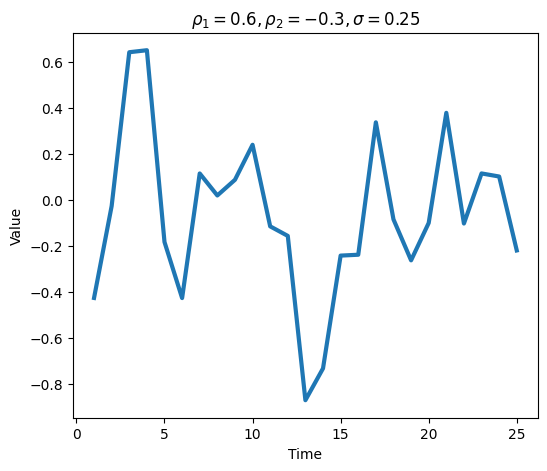

/var/folders/hs/sjsb0x2s0gg5xm3rz3s8n9t00000gn/T/ipykernel_53327/1051452920.py:15: RuntimeWarning: invalid value encountered in sqrt
  ll += norm.logpdf(dat[i], loc=0, scale=np.sqrt(sigma**2 / (1 - rho1**2 - rho2**2)))


Theta (whitened MLE): [ 0.6 -0.3  0.3]


ValueError: The input matrix must be symmetric positive semidefinite.

In [93]:
import numpy as np
from scipy.stats import norm, multivariate_normal
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Function to compute the log-likelihood using the whitened approach
def ar2_loglik_whitened(theta, dat):
    """Compute the log-likelihood of an AR(2) model assuming a whitened noise approach."""
    rho1, rho2, sigma = theta  # Unpack parameters
    T = len(dat)  # Length of the data series
    ll = 0  # Initialize log-likelihood counter
    
    for i in range(T):
        if i == 0:
            ll += norm.logpdf(dat[i], loc=0, scale=np.sqrt(sigma**2 / (1 - rho1**2 - rho2**2)))
        elif i == 1:
            ll += norm.logpdf(dat[i], loc=rho1 * dat[i-1], scale=sigma)
        else:
            ll += norm.logpdf(dat[i], loc=rho1 * dat[i-1] + rho2 * dat[i-2], scale=sigma)
    
    return ll

# Function to compute the log-likelihood using the joint likelihood approach
def ar2_loglik_joint(theta, dat):
    """Compute the log-likelihood of an AR(2) model using the full joint likelihood approach."""
    rho1, rho2, sigma = theta  # Unpack parameters
    T = len(dat)  # Length of the data series
    
    # Construct the covariance matrix for AR(2) using Toeplitz structure
    H = np.abs(np.arange(T)[:, None] - np.arange(T))
    P = rho1 ** H + rho2 ** (H - 1) * (H > 0)  # Apply rho2 only for lags greater than 1
    Sigma = (sigma**2 / (1 - rho1**2 - rho2**2)) * P
    
    ll = multivariate_normal.logpdf(dat, mean=np.zeros(T), cov=Sigma)
    return ll

# Parameters for AR(2) process
rho1 = 0.6  # First autoregressive coefficient
rho2 = -0.3  # Second autoregressive coefficient
sigma = 0.25  # Standard deviation of noise
T = 25  # Length of time series

# Simulate synthetic AR(2) time series
ts_sim = np.zeros(T)  # Initialize time series array
for t in range(T):
    if t == 0:
        ts_sim[t] = np.random.normal(0, np.sqrt(sigma**2 / (1 - rho1**2 - rho2**2)))
    elif t == 1:
        ts_sim[t] = np.random.normal(rho1 * ts_sim[t-1], sigma)
    else:
        ts_sim[t] = np.random.normal(rho1 * ts_sim[t-1] + rho2 * ts_sim[t-2], sigma)

# Plot the simulated time series
plt.figure(figsize=(6, 5))
plt.plot(range(1, T+1), ts_sim, linewidth=3)
plt.xlabel("Time")
plt.ylabel("Value")
plt.title(r"$\rho_1 = 0.6, \rho_2 = -0.3, \sigma = 0.25$")
plt.show()

# Optimization bounds and initial parameter guess
lb = [-0.99, -0.99, 0.01]  # Lower bounds for parameters
ub = [0.99, 0.99, 5]  # Upper bounds for parameters
init = [0.6, -0.3, 0.3]  # Initial guesses for parameters
bounds = [(lb[i], ub[i]) for i in range(3)]  # Combine bounds into a list of tuples

# Optimize parameters using the whitened likelihood approach
optim_whitened = minimize(lambda theta: -ar2_loglik_whitened(theta, ts_sim), init, bounds=bounds)
theta_wn_mle = np.round(optim_whitened.x, 2)  # Round results to two decimal places
print("Theta (whitened MLE):", theta_wn_mle)

# Optimize parameters using the joint likelihood approach
optim_joint = minimize(lambda theta: -ar2_loglik_joint(theta, ts_sim), init, bounds=bounds)
theta_joint_mle = np.round(optim_joint.x, 2)  # Round results to two decimal places
print("Theta (joint MLE):", theta_joint_mle)


NOW: Use your model to simulate 1,000 realizations of hourly tide gauge observations by adding simulations from your AR model back to the predicted sinusoidal trend. What is the distribution of the maximum tide level? How does this compare to the observed value?

## Problem 3

The file `data/salamanders.csv` contains counts of salamanders from 47
different plots of the same area in California, as well as the
percentage of ground cover and age of the forest in the plot. You would
like to see if you can use these data to predict the salamander counts
with a Poisson regression.

**In this problem**:

-   Load the data. You may need to standardize the predictors as they
    are much larger than the counts.
-   Fit a Poisson regression model for salamander counts using the
    percentage of ground cover.
-   Plot the expected counts and 90% prediction intervals from your
    model. How well does the model predict the observed counts? In what
    ways does it do a good or bad job?
-   Can you improve the model by including forest age? Why do you think
    this helps or does not help with prediction?

In [107]:
# Note - I asked chatgpt (openai, 2024) how to read in a csv that used semi colon as a delimiter (because this one loaded incorrectly due to that fact); based on its answer I added
# delimiter=";" to the code below.
sal = pd.read_csv("data/salamanders.csv", delimiter=";") 
print(sal.head(5))

   SITE  SALAMAN  PCTCOVER  FORESTAGE
0     1       13        85        316
1     2       11        86         88
2     3       11        90        548
3     4        9        88         64
4     5        8        89         43


In [108]:
# standardize predictors
sal['PCTCOVER_scale'] = (sal['PCTCOVER'] - sal['PCTCOVER'].mean())/sal['PCTCOVER'].std()
sal['FORESTAGE_scale'] = (sal['FORESTAGE'] - sal['FORESTAGE'].mean())/sal['FORESTAGE'].std()

The structure of my poisson model is:

$y_i \sim Poisson(\lambda_i)$

$f(\lambda_i) = beta_0 + beta_1 * PCTCOVER$

$\lambda_i = f^{-1} (beta_0 + beta_1 * PCTCOVER)$

And for this Poisson model, I think it makes sense to use the log link function (converting all real numbers that come out of the $beta_0 + beta_1 * PCTCOVER$ into only postive rate constant values).

So my model would be:

$y_i \sim Poisson(\lambda_i)$ where $\lambda_i = e\^{}(beta_0 + beta_1 * PCTCOVER)$

To beging coding this, I first converted the code from the lecture slides on probability models from Julia to Python using chatgpt (openai, 2025). The output from chatgpt is shown below, commented out. I then used this outline of the workflow to create my salamander model.

In [109]:
# import numpy as np
# from scipy.stats import poisson
# from scipy.optimize import minimize

# # Define the model function using scipy's Poisson logpmf
# def fish_model(params, persons, hours, fish_caught):
#     β0, β1, β2 = params
#     λ = np.exp(β0 + β1 * persons + β2 * hours)  # Compute λ for each observation
#     loglik = np.sum(poisson.logpmf(fish_caught, λ))  # Compute log-likelihood
#     return loglik

# # Bounds and initial values
# lb = [-100.0, -100.0, -100.0]
# ub = [100.0, 100.0, 100.0]
# init = [0.0, 0.0, 0.0]

# # Example data (replace with actual dataset)
# persons = np.array([1, 2, 3, 4, 5])
# hours = np.array([2, 3, 5, 7, 9])
# fish_caught = np.array([1, 0, 3, 4, 6])

# # Optimization (maximize log-likelihood, so minimize negative log-likelihood)
# optim_out = minimize(lambda θ: -fish_model(θ, persons, hours, fish_caught), init, bounds=list(zip(lb, ub)))

# # Extract MLE estimates
# θ_mle = optim_out.x
# print(np.round(θ_mle, 1))


In [117]:
# sal['SALAMAN'].mean()

In [118]:
# np.log(sal['SALAMAN'].mean())

Note that the way I chose the lower and upper bounds below as as follows: I know that my average count of salamanders is 2.46, meaning my funciton e^(β0 + β1 * pct_cover) should result in something vaguely in the ballpark of 2.46; meaning β0 + β1 * pct_cover is somewhere around ln(2.46) = 0.9034. Since I've already centered and scaled my variables, I certainly don't need lower and upper bounds of -100 and 100; I reduced them to -10 and 10 knowing that this is still very vague.

In [120]:
# Fit poisson regression salamander counts ~ Poisson(rate dependent on percent ground cover)
from scipy.stats import poisson
from scipy.optimize import minimize

# Define the model function using scipy's Poisson logpmf
def salamander_model(params, pct_cover, sal_count):
    β0, β1 = params
    λ = np.exp(β0 + β1 * pct_cover)  # Compute λ for each observation
    loglik = np.sum(poisson.logpmf(sal_count, λ))  # Compute log-likelihood
    return loglik

# Bounds and initial values
lb = [-10.0, -10.0]
ub = [10.0, 10.0]
init = [0.0, 0.0]

# Optimization (maximize log-likelihood, so minimize negative log-likelihood)
optim_out = minimize(lambda θ: -salamander_model(θ, pct_cover = sal['PCTCOVER_scale'], sal_count=sal['SALAMAN']), init, bounds=list(zip(lb, ub)))

# Extract MLE estimates
θ_mle = optim_out.x
β0_hat, β1_hat = θ_mle
print('Estimate of β0_hat: ',np.round(β0_hat, 2), 'Estimate of β1_hat: ', np.round(β1_hat, 2))


Estimate of β0_hat:  0.43 Estimate of β1_hat:  1.16


Next I plotted the expected counts and 90% prediction intervals from my model:

In [124]:
# Compute predicted lambda values
λ_hat = np.exp(β0_hat + β1_hat * sal['PCTCOVER_scale'])
print('λ_hat: ', λ_hat)
# Compute 90% prediction intervals (5th and 95th percentiles of the Poisson distribution)
lower_bound = poisson.ppf(0.05, λ_hat)
upper_bound = poisson.ppf(0.95, λ_hat)

# Print results
for i in range(len(sal['PCTCOVER_scale'])):
    print(f"Prediction Interval for PCTCOVER_scale {sal['PCTCOVER_scale'][i]}: [{lower_bound[i]}, {upper_bound[i]}]")


λ_hat:  0     3.571004
1     3.688635
2     4.199201
3     3.935647
4     4.065289
5     3.346878
6     3.346878
7     4.337524
8     3.935647
9     4.199201
10    3.810140
11    3.346878
12    3.810140
13    4.065289
14    4.480404
15    4.627990
16    0.242407
17    3.810140
18    4.627990
19    0.285050
20    0.381591
21    0.420556
22    0.581536
23    0.683837
24    1.008917
25    3.036786
26    3.688635
27    3.935647
28    4.480404
29    0.227193
30    0.234676
31    0.250392
32    0.267159
33    0.294439
34    0.304138
35    0.324505
36    0.357641
37    0.394161
38    0.494538
39    0.945595
40    1.225482
41    2.755424
42    2.846188
43    3.036786
44    3.688635
45    4.065289
46    4.337524
Name: PCTCOVER_scale, dtype: float64
Prediction Interval for PCTCOVER_scale 0.727323099373052: [1.0, 7.0]
Prediction Interval for PCTCOVER_scale 0.755274191499408: [1.0, 7.0]
Prediction Interval for PCTCOVER_scale 0.8670785600048322: [1.0, 8.0]
Prediction Interval for PCTCOVER_scale 0.8

How well does the model predict the observed counts? In what ways does it do a good or bad job? Can you improve the model by including forest age? Why do you think this helps or does not help with prediction?

### Problem 4

<span style="color:red;">GRADED FOR 5850 STUDENTS ONLY</span>

In 2014, [a paper was published in a prestigious
journal](https://www.pnas.org/doi/10.1073/pnas.1402786111) which claimed
that hurricanes with more feminine names are deadlier than hurricanes
with more masculine names because people take warnings about
female-named hurricanes less seriously[1]. The file
`data/Hurricanes.csv` contains the original data used in this analysis.
While we won’t replicate the specific analysis in this paper, let’s use
the data to look at this hypothesis.

**In this problem**:

-   One might interpret the hypothesis to claim that the impact of the
    name is strengthened by the the more powerful. A measure of
    hurricane strength is its minimum pressure (`min_pressure` in the
    dataset). Fit a model that predicts deaths (‘deaths’) using the
    femininity of the name (`femininity`) and minimum pressure (you may
    need to standardize the pressure).
-   Interpret the results by generating counterfactual simulations for
    hurricanes with the most feminine and masculine name scores. Plot
    the expected values and 90% prediction intervals from these two sets
    of simulations and compare with the observed storm deaths. Where
    does the model do well or not well? Does the effect size of the
    gender of the name seem plausible?
-   Conclude with a summary of your conclusions about the impact of the
    gender of a hurricane’s name on deaths. How might you change the
    approach in this problem to keep exploring this hypothesis, if at
    all?

[1] This paper has become a bit of a joke among statisticians, but let’s
take the hypothesis seriously for this problem’s sake.

In [127]:
hur = pd.read_csv('data/Hurricanes.csv', delimiter=";")
print(hur.head(5))

       name  year  deaths  category  min_pressure  damage_norm  female  \
0      Easy  1950       2         3           960         1590       1   
1      King  1950       4         3           955         5350       0   
2      Able  1952       3         1           985          150       0   
3   Barbara  1953       1         1           987           58       1   
4  Florence  1953       0         1           985           15       1   

   femininity  
0     6.77778  
1     1.38889  
2     3.83333  
3     9.83333  
4     8.33333  


In [132]:
# hur.dtypes

In [ ]:
# Fit model: deaths = f(femininity, pressure)

# first standardize pressure:
hur['min_pressure_scaled'] = (hur['min_pressure'] - hur['min_pressure'].mean())/hur['min_pressure'].std()



## References

OpenAI. (2024). ChatGPT (Feb 12 version) [Large language model]. https://chatgpt.com/


Statsmodels. (2024). statsmodels.tsa.stattools.pacf documentation. https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.pacf.html 